## 1. Import Libraries and Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

from module_function import (cross_validate_model,plot_all_modelsRegression_predictions,
                             evaluate_models_Regression,feature_importance,plot_residuals,Hyperparameter_Tuning,plot_tuned_feature_importance)

import warnings
warnings.filterwarnings("ignore")

import pickle

In [3]:
df = pd.read_csv('dataset/diamonds_CLEANING.csv')
df_x = df.drop(columns='price')
df_y = df['price']

In [4]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 37932 samples
Test set: 9484 samples


## 2. Feature Scaling

In [6]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

## 3.Pipeline All Models Regression

In [8]:
n = 17
regresi_pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', LinearRegression())
    ]),
    
    'Ridge Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Ridge(alpha=1.0))
    ]),
    
    'Lasso Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Lasso(alpha=1.0, random_state=42, max_iter=10000))
    ]),
    
    'Random Forest Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    
    'Gradient Boosting Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', GradientBoostingRegressor(random_state=42))
    ]),
    
    'XGBoost Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [10]:
predictions_dict = {}
for model_name, pipeline in regresi_pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evaluate_models_Regression( model_dict=predictions_dict, y_test=y_test)
df_report.sort_values(by='R2-Score', ascending=False)

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses Training Selesai!


,Model,R2-Score,MAE,MSE,RMSE
5,XGBoost Regressor,0.9841,190.4704,120879.1797,347.6768
3,Random Forest Regressor,0.9830,192.2181,129443.5998,359.7827
4,Gradient Boosting Regressor,0.9797,228.4865,154833.0647,393.4883
0,Linear Regression,0.9224,539.2878,590703.6821,768.5725
1,Ridge Regression,0.9200,542.9869,609240.6828,780.5387
2,Lasso Regression,0.9178,551.8985,625683.3926,791.0015


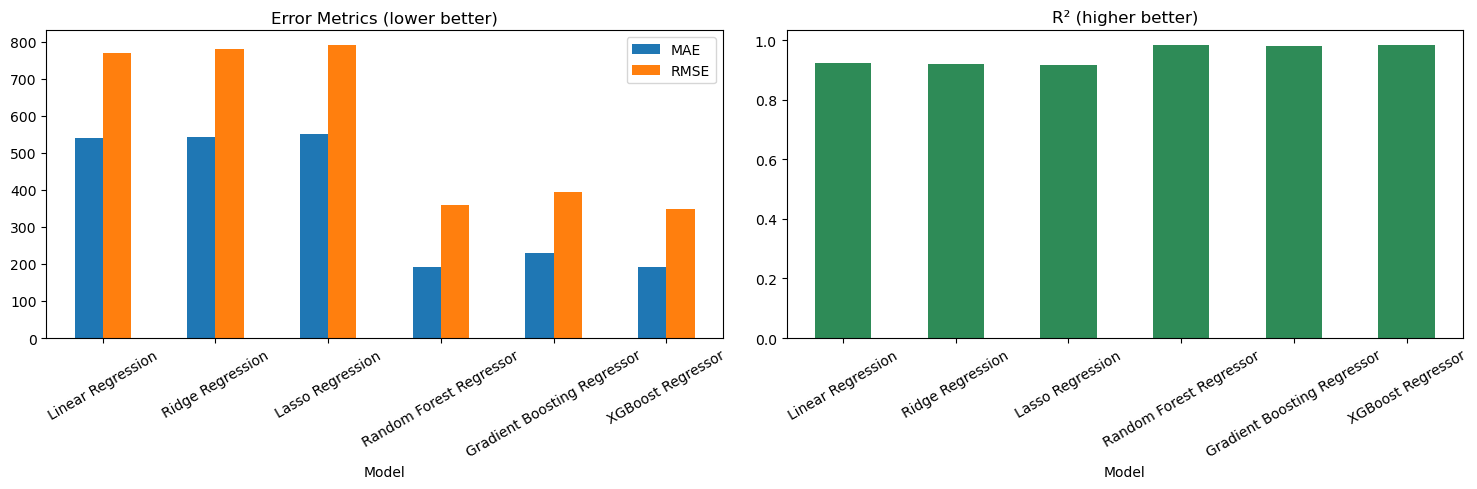

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5.Analysis Model Sesudah Cross-Validate

In [13]:
df_hasil_perbandingan = cross_validate_model(models_dict=regresi_pipelines, X=X_train, y=y_train, cv_folds=5, mode='regression')
df_hasil_perbandingan.sort_values(by='R2-Score', ascending=False)

=== MENJALANKAN 5-FOLD CROSS VALIDATION (REGRESI) ===

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses CV Selesai!


,Model,R2-Score,MAE,MSE,RMSE
5,XGBoost Regressor,0.984260,190.630042,118820.579687,344.703611
3,Random Forest Regressor,0.982995,193.486182,128403.368867,358.334158
4,Gradient Boosting Regressor,0.979939,229.368131,151457.014846,389.174787
0,Linear Regression,0.921609,540.603767,592108.101594,769.485608
1,Ridge Regression,0.919124,546.377489,610985.180374,781.655410
2,Lasso Regression,0.917274,554.492106,624981.690148,790.557835


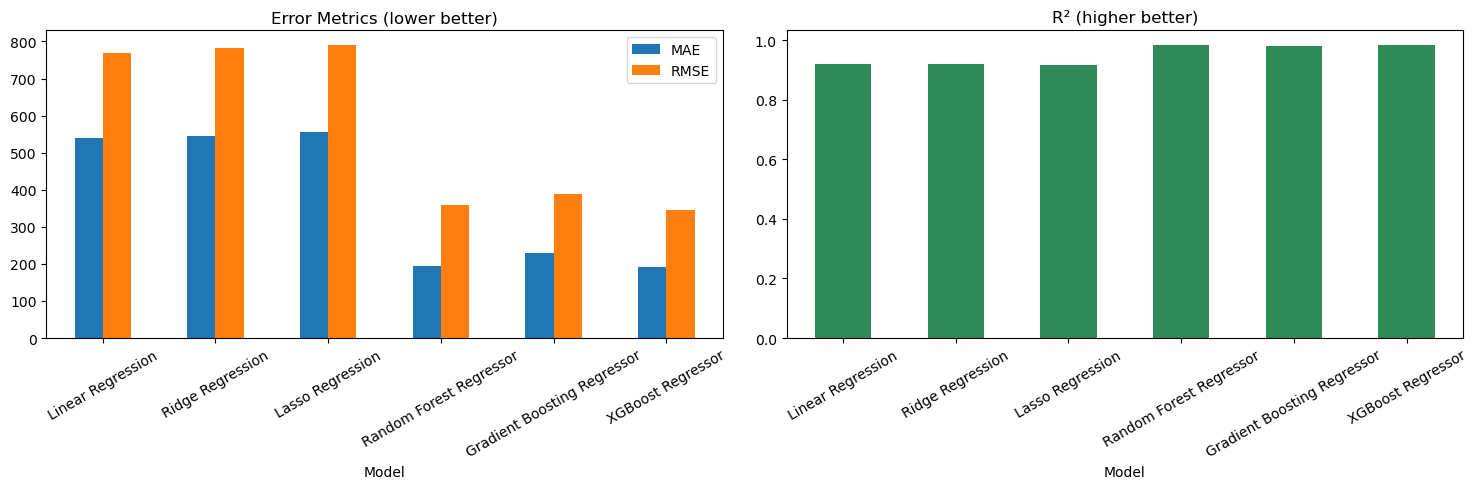

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_hasil_perbandingan.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_hasil_perbandingan.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6. Analysis Nilai Asli dan Nilai Prediksi

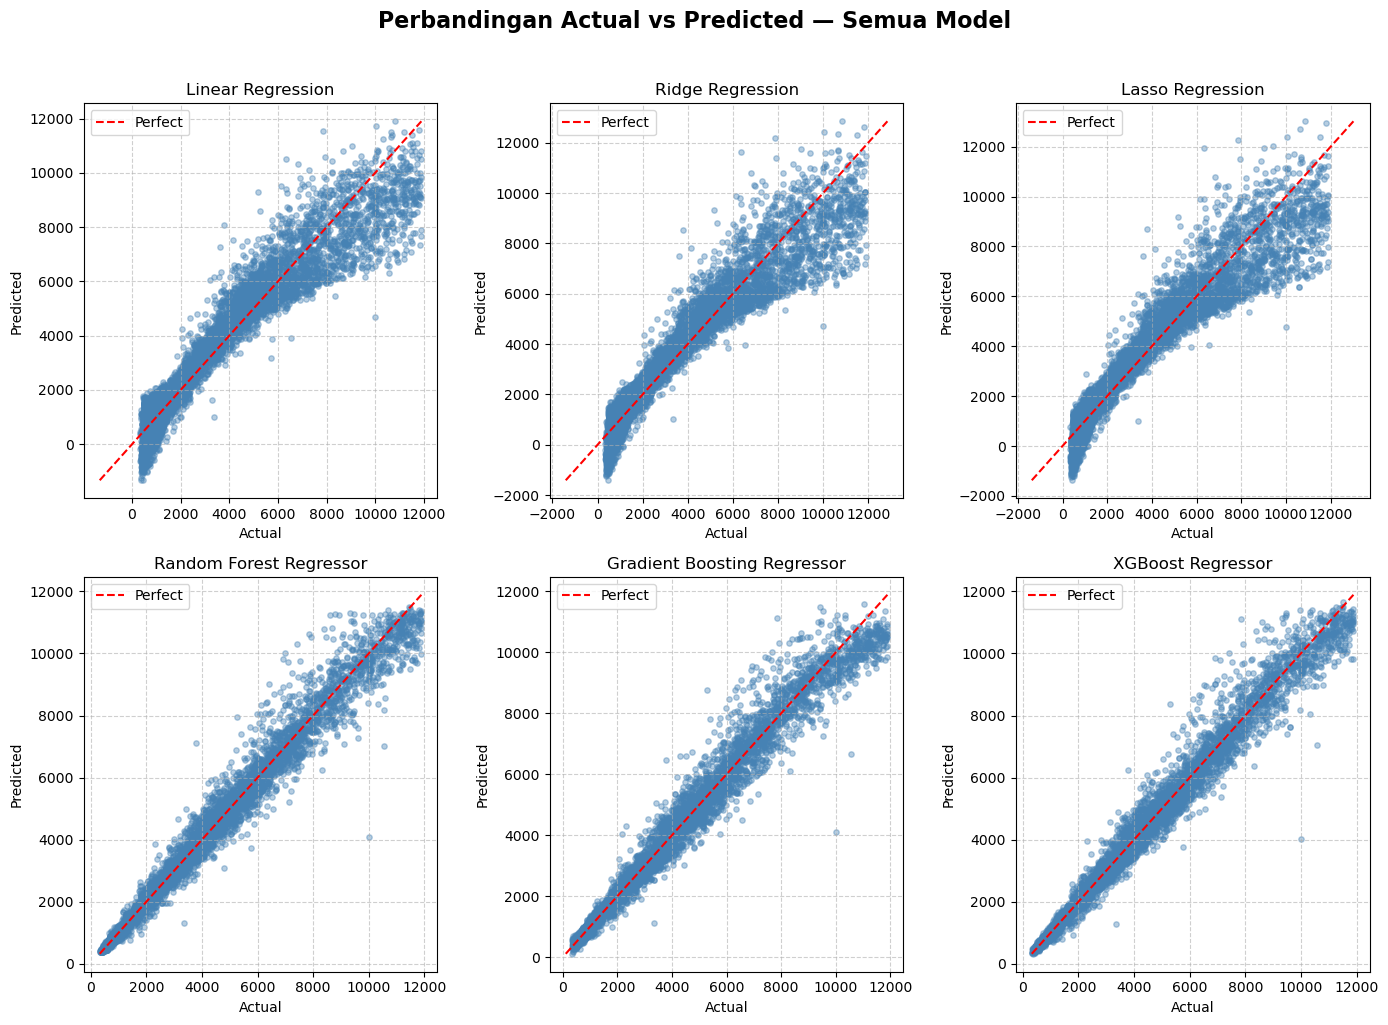

In [16]:
plot_all_modelsRegression_predictions( models_dict=regresi_pipelines, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,)

## 7. Importance Feature for Models

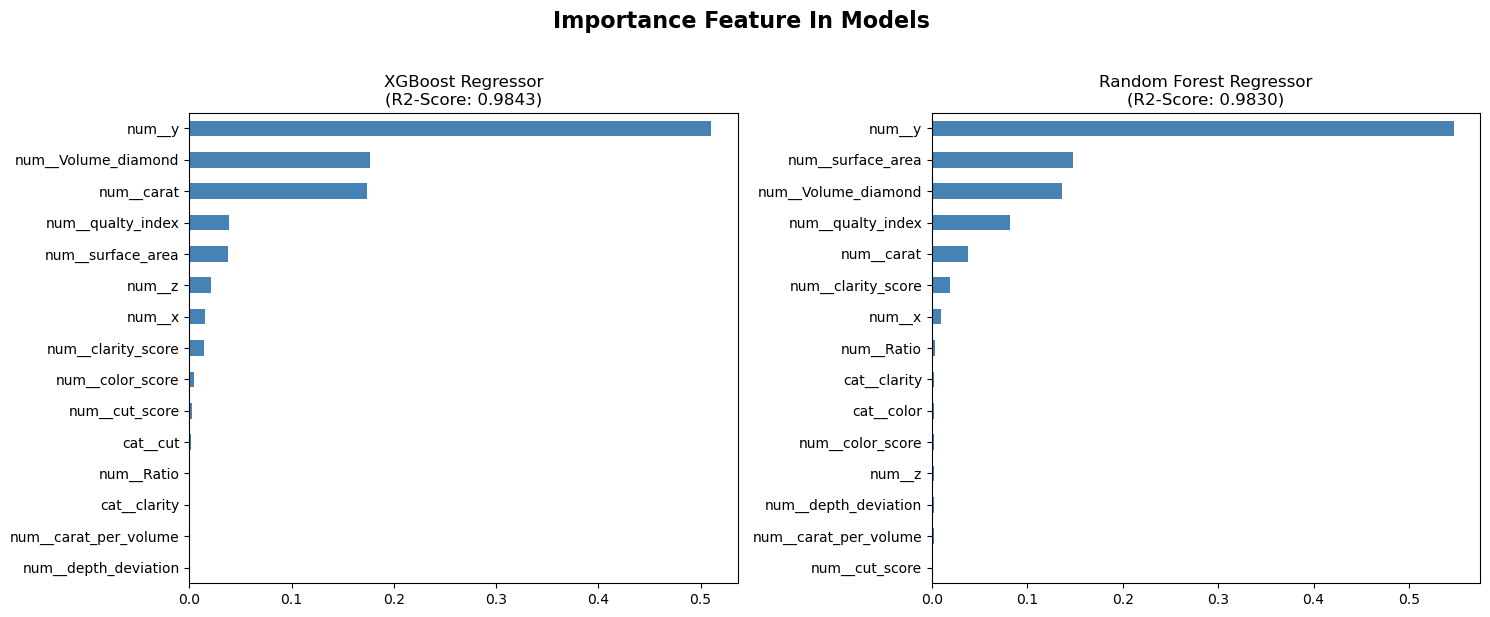

In [18]:
feature_importance(result_crossValidate=df_hasil_perbandingan,model_dict=regresi_pipelines)

## 8. Analysis Residuals — Best Model

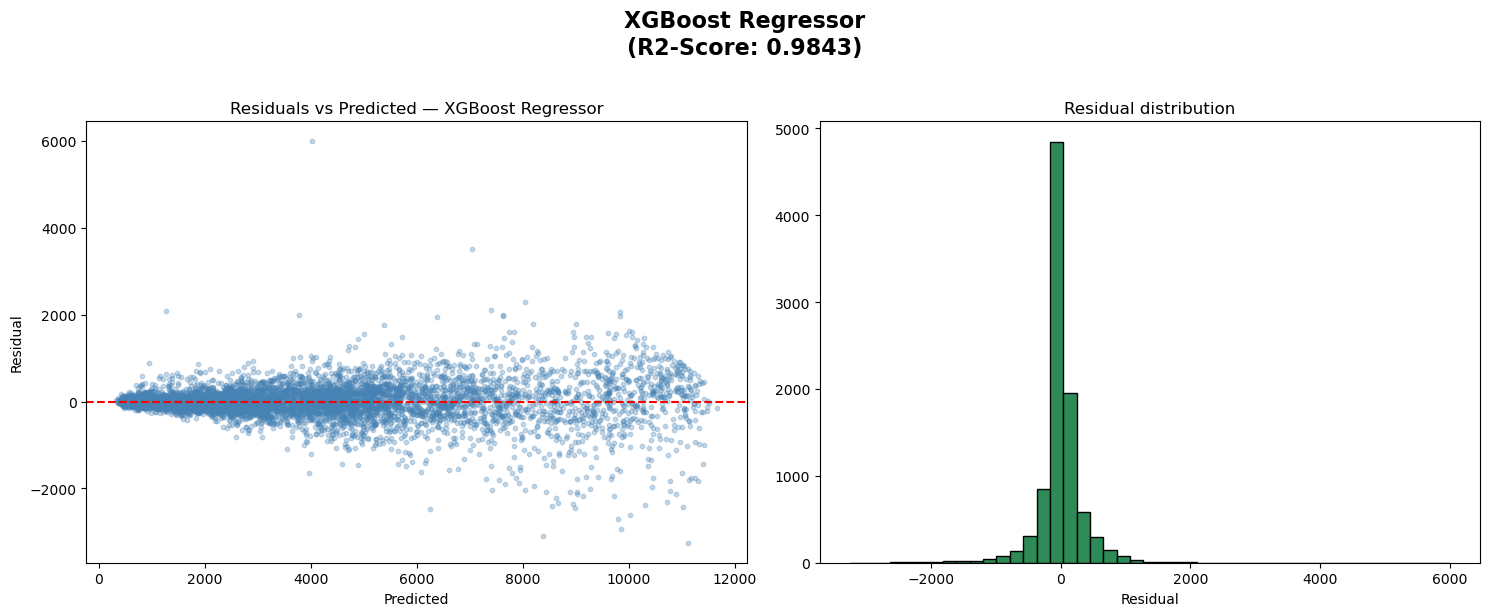

In [20]:
plot_residuals(result_crossValidate=df_hasil_perbandingan,model_dict=regresi_pipelines,x_test=X_test,y_test=y_test)

## 9. Hyperparameter Tuning — Best Performer

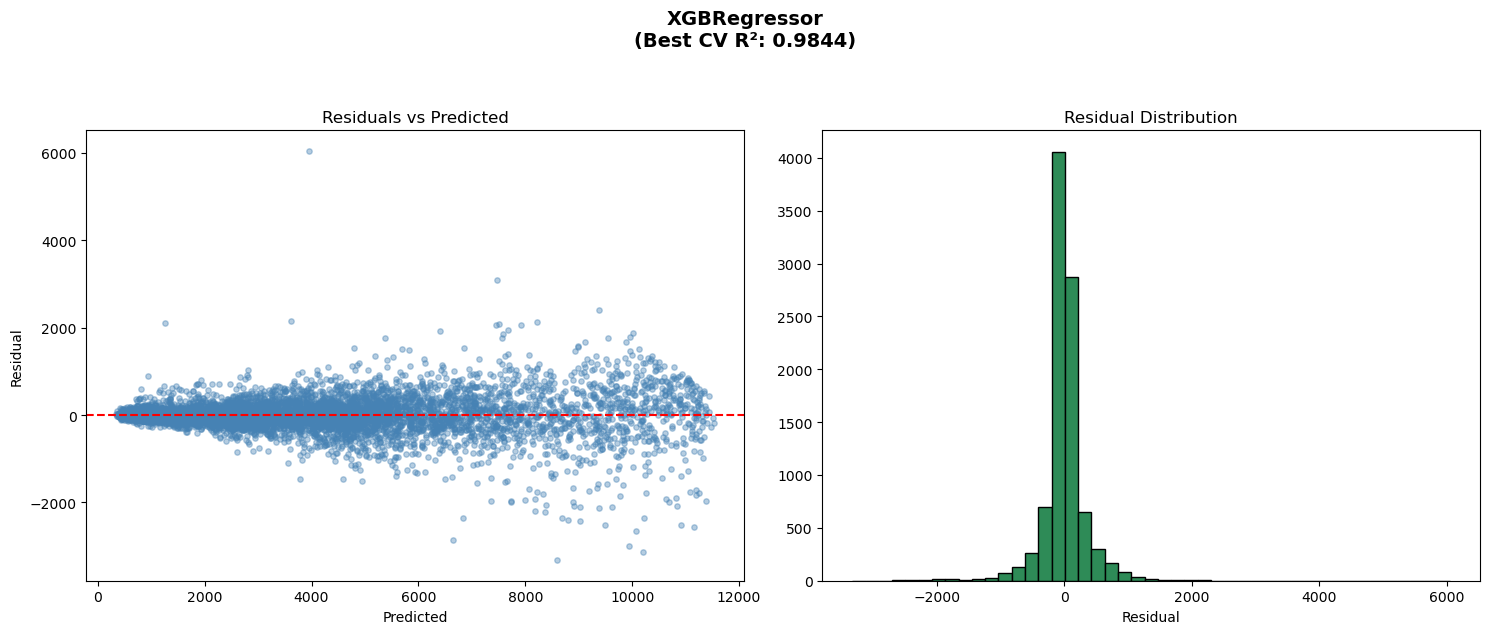

In [22]:
pipeline_model = regresi_pipelines['XGBoost Regressor']
params = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__gamma': [0, 0.1, 0.2]
}
best_model = Hyperparameter_Tuning(method='randomcv',pipeline_model=pipeline_model,cv=5,type_model='regression',
                                   param=params,x_train=X_train,y_train=y_train,x_test=X_test,y_test=y_test)

## 9. Tuned Model — Feature Importance

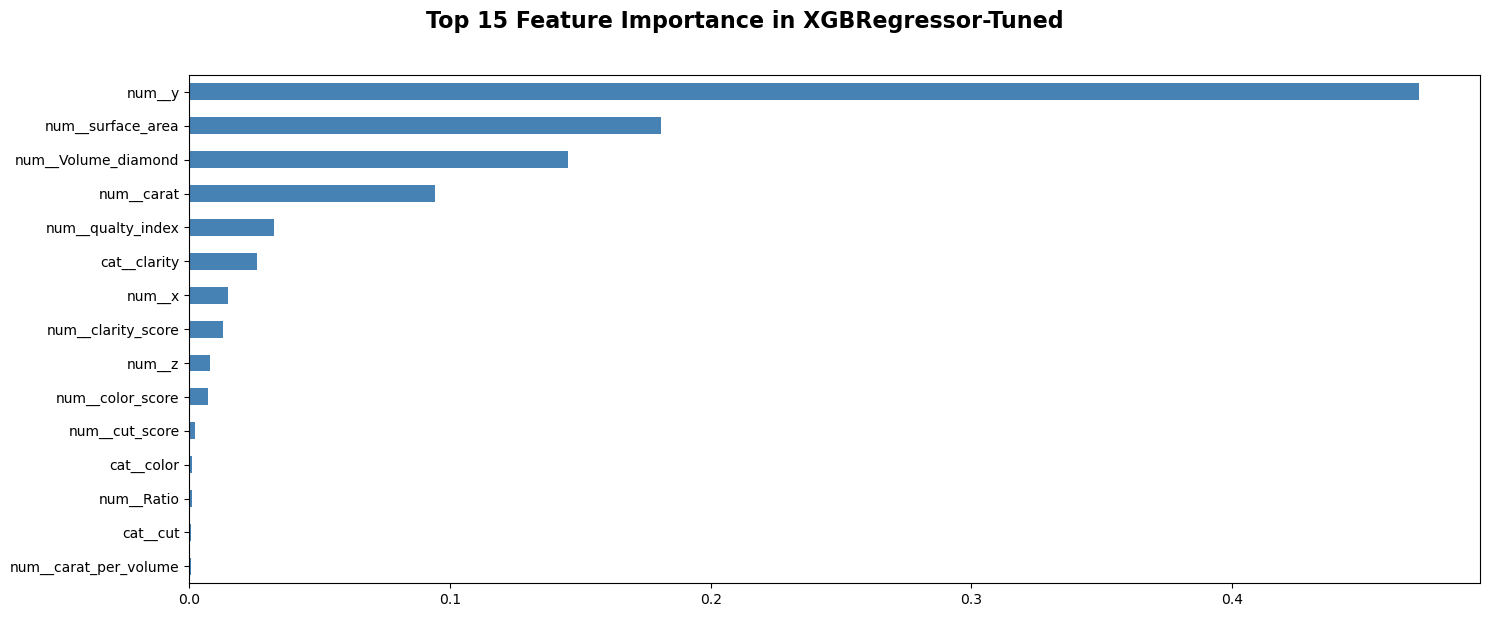

In [24]:
plot_tuned_feature_importance(tuned_model=best_model)

## 10. Simple Prediction

In [26]:
sample = X_test.iloc[:7].copy()
preds = best_model.predict(sample)

result = pd.DataFrame({'Predicted' : preds.round(2),
                       'Actual': y_test.iloc[:7].values.round(2)})
result['AbsError'] = (result['Predicted'] - result['Actual']).abs().round(2)
result

,Predicted,Actual,AbsError
0,1719.750000,1800,80.25
1,5578.200195,4900,678.20
2,431.429993,432,0.57
3,660.710022,666,5.29
4,546.580017,571,24.42
5,719.260010,586,133.26
6,923.049988,1020,96.95


## 11. Save Model

In [28]:
with open('Diamont_Price_Prediction', 'wb') as f:
    pickle.dump(best_model, f)